# NB02c: CARD-BS DOWNLOAD

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.

Downloads CARD-BS zips from `nb02a_scene_plan.json`.  
CARD entries have no scene_id — forces CDSE search (IW_GRDH + CARD_BS filter).  
Uses proven search+download from v14.

# NB02c — Sentinel-1 CARD-BS Backscatter Download

<!--
SPDX-License-Identifier: MIT
Text and figures: CC BY 4.0 (https://creativecommons.org/licenses/by/4.0/)
Code: MIT License (https://opensource.org/licenses/MIT)
Published: https://github.com/marcoheinzen/bda
Author: Marco Heinzen
-->

| Field | Value |
|-------|-------|
| **Notebook** | `02c_card_download_v18.ipynb` |
| **Version** | v18 |
| **Pipeline position** | Acquisition. After NB02a (plan), before NB03b (CARD clipping). |
| **License** | Code: MIT / Text and figures: CC BY 4.0 |
| **Repository** | [github.com/marcoheinzen/bda](https://github.com/marcoheinzen/bda) |
| **Last validated** | 2026-04-XX |

## Narrative

Downloads Sentinel-1 CARD-BS (Copernicus Analysis Ready Data — Backscatter) zips
from the Copernicus Data Space for dates listed in `nb02a_scene_plan.json`.

Unlike SLC scenes, CARD entries in the plan have no `scene_id` — the notebook must
search CDSE for IW_GRDH products with the CARD-BS filter to find the correct product.
This search-then-download pattern differs from NB02b (MS) which downloads by product ID.

CARD-BS products are radiometrically calibrated and terrain-corrected sigma0 in linear
power. Downstream conversion to dB (10 * log10) happens in NB03b.

CARD orbit (`orbit_card`) is independent from SLC/COH orbit. NB02a produces
`orbit_card` per city in the plan by reading `recommended_orbit_card` from `cities_df`
(defaults to SLC orbit if column absent). A city may use different ascending/descending
orbits for CARD vs coherence. This independence is tracked throughout the pipeline.

## Scientific Rationale
CARD-BS provides analysis-ready backscatter without requiring SNAP processing, unlike
SLC-derived coherence which needs GPT graph processing. Backscatter changes between
pre-battle baseline and battle/post-battle periods indicate structural damage: destroyed
buildings cause increased double-bounce loss and altered scattering geometry. Dietrich
et al. (2025) use VV/VH backscatter statistics (min, max, mean, median, std, kurtosis,
skewness) as 14 of their 28 features.

## Inputs

| Data | Source | Format |
|------|--------|--------|
| `nb02a_scene_plan.json` | NB02a Cell PLAN | JSON (CARD dates + `orbit_card` per city) |
| Copernicus Data Space | Online | Sentinel-1 CARD-BS zips |

## Outputs

| Artifact | Path | Used by |
|----------|------|---------|
| CARD-BS zip files | `CARD_ZIP_DIR/{scene_name}.zip` | NB03b (extraction + clipping) |
| Updated `nb02a_scene_plan.json` | `OUTPUTS_DIR/` | NB03b (status tracking) |

## Prerequisites
- NB02a must have run (plan exists with CARD dates and `orbit_card`)
- Copernicus Data Space credentials in `global_setup`
- Internet access

## Key Methodological Choices

| Choice | Justification | Reference |
|--------|---------------|-----------|
| Search CDSE per date (no cached ID) | CARD products lack stable scene_id in plan | CDSE API limitation |
| IW_GRDH + CARD_BS filter | Standard CARD product type | Copernicus documentation |
| CARD_SEARCH_FALLBACK_DAYS=0 | Strict date match, no neighboring dates | Data integrity |
| EXTRACT_AFTER_DOWNLOAD=False | Extraction handled by NB03b | Separation of concerns |
| orbit_card from NB02a plan | CARD and SLC orbits may differ per city | scene_plan.py reads recommended_orbit_card |

## Known Limitations
- CARD availability may lag SLC by days on CDSE
- Multi-orbit CARD contamination possible if orbit not locked per city (NB03b zigzag bug, resolved)
- CARD entries have no scene_id — requires CDSE re-search at download time

## Cell Structure

| Cell | ID | What | Status |
|------|----|------|--------|
| 0 | — | Documentation (this cell) | — |
| 1 | Cell 3 | Config (TIER_SELECTION, DRY_RUN, FALLBACK_DAYS) | Config |
| 2 | Cell 4 | Load global_setup | Config |
| 3-4 | Cell LOAD-PLAN | Load plan + filter by tier + recheck disk | **Core** |
| 5-6 | Cell DL-CARD | CARD-BS search CDSE + download loop | **Core** |
| 7 | Cell SUMMARY | Save updated plan + completion summary | **Core** |

## Thesis Mapping

| Thesis Section | Cells | Content |
|----------------|-------|---------|
| 3.2 Data Sources — Sentinel-1 CARD-BS | DL-CARD | CARD-BS product description, orbit independence |
| 3.3 Preprocessing — Acquisition Pipeline | LOAD-PLAN, DL-CARD | Search-based download, plan-driven |

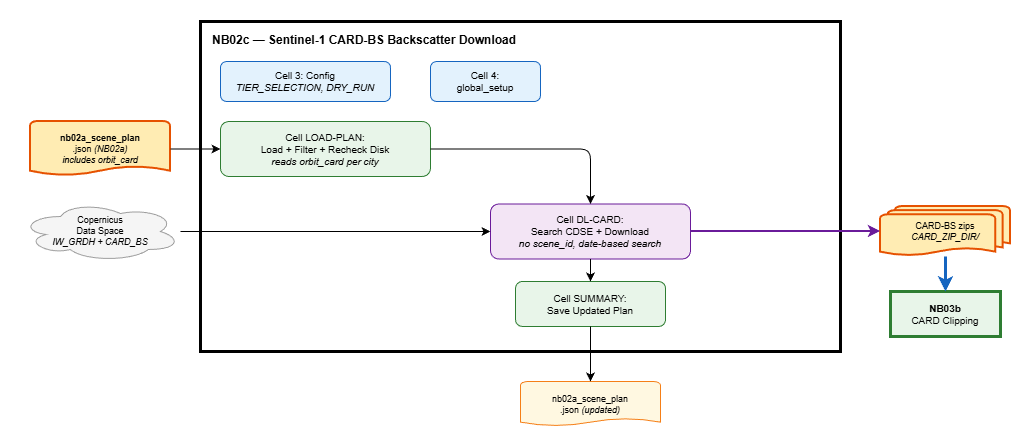

In [1]:
# @title CELL 3: NB02c CONFIG
TIER_SELECTION = [0, 1, 2,3,4,5]
CITY_SELECTION = None
FORCE_RERUN = False
DRY_RUN = False
EXTRACT_AFTER_DOWNLOAD = False
CARD_SEARCH_FALLBACK_DAYS = 0

In [2]:
# @title CELL 4: LOAD GLOBAL SETUP
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())

/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


BDA GLOBAL SETUP
Started: 2026-04-09 21:21:39
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------
  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2, 3, 4, 5]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: False
  CITIES_TO_PROCESS: 50 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:532: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     912.4/7452.0 GB (6539.7 GB free)
  GDrive (F:)     967.1/3726.0 GB (2758.9 GB free)
  Local data      12017.8/14901.9 GB (2884.1 GB free)
  Data stack      967.1/3726.0 GB (2758.9 GB free)
  WSL ext4        128.7/1006.9 GB (826.9 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 50, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_b

# LOAD PLAN + RECHECK DISK

In [3]:
# @title CELL LOAD-PLAN: LOAD PLAN + FILTER + RECHECK DISK
import json, re, zipfile
from pathlib import Path
from datetime import datetime

PLAN_FILE = OUTPUTS_DIR / 'nb02a_scene_plan.json'
if not PLAN_FILE.exists():
    raise FileNotFoundError(f"Plan not found: {PLAN_FILE}\nRun NB02a first.")

with open(PLAN_FILE) as f:
    PLAN = json.load(f)

print("=" * 80)
print("NB02c: LOADING PLAN + RECHECKING CARD DATA")
print("=" * 80)

card_plan = {}
for city, plan in PLAN.items():
    tier = plan.get('tier', 99)
    if TIER_SELECTION and tier not in TIER_SELECTION:
        continue
    if CITY_SELECTION and city not in CITY_SELECTION:
        continue
    card_plan[city] = plan

print(f"  Cities after filter: {len(card_plan)}")

# Recheck CARD zips + TIFs
CARD_ZIP_DIR.mkdir(parents=True, exist_ok=True)
SAR_CARD_DIR.mkdir(parents=True, exist_ok=True)

card_zip_dates = set()
for f in CARD_ZIP_DIR.iterdir():
    if f.suffix == '.zip' and 'CARD_BS' in f.name:
        m = re.search(r'_(\d{8})T', f.name)
        if m:
            d = m.group(1)
            card_zip_dates.add(f"{d[:4]}-{d[4:6]}-{d[6:8]}")

card_tif_dates = {}
for city_dir in SAR_CARD_DIR.iterdir():
    if not city_dir.is_dir():
        continue
    dates = {}
    for tif in city_dir.rglob("*.tif"):
        m = re.search(r'(\d{8})', tif.stem)
        pol_m = re.search(r'(VV|VH)', tif.stem, re.IGNORECASE)
        if m and pol_m:
            d = m.group(1)
            ds = f"{d[:4]}-{d[4:6]}-{d[6:8]}"
            if ds not in dates:
                dates[ds] = set()
            dates[ds].add(pol_m.group(1).upper())
    card_tif_dates[city_dir.name] = {d for d, pols in dates.items() if 'VV' in pols and 'VH' in pols}

download_queue = []
on_disk_count = 0

for city, plan in sorted(card_plan.items(), key=lambda x: (x[1]['tier'], x[0])):
    city_tifs = card_tif_dates.get(city, set())
    for entry in plan.get('card', []):
        date = entry.get('date', '')
        has_zip = date in card_zip_dates
        has_tif = date in city_tifs
        if has_zip or has_tif:
            entry['status'] = 'on_disk'
            on_disk_count += 1
        elif entry['status'] == 'on_disk':
            entry['status'] = 'to_download'
        if entry['status'] == 'to_download':
            download_queue.append({
                'city': city, 'tier': plan['tier'],
                'orbit': plan.get('orbit'),
                'period': entry.get('period', ''), 'date': date,
                'scene_name': entry.get('scene_name', ''),
                'scene_id': entry.get('scene_id', ''),
            })

print(f"  On disk: {on_disk_count}")
print(f"  To download: {len(download_queue)}")
download_queue.sort(key=lambda x: (x['tier'], x['city'], x['date']))
print("=" * 80)

NB02c: LOADING PLAN + RECHECKING CARD DATA
  Cities after filter: 50
  On disk: 2194
  To download: 78


# DOWNLOAD

In [4]:
# @title CELL DL-CARD: CARD-BS DOWNLOAD (PLAN-BASED, INDEPENDENT)
# =============================================================================
# Downloads Sentinel-1 CARD-BS for dates defined in card_download_plan.json.
# Fully independent from NB03/InSAR tracker.
#
# CARD-BS = Copernicus Analysis Ready Data - Backscatter
# Contains radiometrically calibrated + terrain-corrected sigma0 in linear power.
# We convert to dB: 10 * log10(sigma0)
#
# Features:
#   - Reads dates from DL-SYNC card_download_plan.json (independent from SLC)
#   - Flat zip storage in CARD_ZIP_DIR (one zip reused for multiple cities)
#   - Per-city TIF output in SAR_CARD/{city}/{period}/
#   - Own card_download_tracker.json
#
# Output: SAR_CARD/{city}/{period}/{city}_CARD_{pol}_{date}.tif
# Requires: Cell 4+4A (paths, credentials), Cell DL-SYNC (plan)
# =============================================================================

import json
import os
import re
import requests
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.mask import mask as rasterio_mask
from rasterio.io import MemoryFile
from rasterio.transform import from_bounds as transform_from_bounds
from pathlib import Path
from datetime import datetime, timedelta
import geopandas as gpd
from shapely.geometry import mapping
import zipfile
import shutil
import time
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION
# =============================================================================

CELL_ID = "cell_dl_card"
FORCE_RERUN = False
DRY_RUN = False
EXTRACT_AFTER_DOWNLOAD = False  # False = download zip only, True = also extract+clip (legacy)
SEARCH_WINDOW_DAYS = CARD_SEARCH_FALLBACK_DAYS

COP_USER = os.environ.get('COP_U', '')
COP_PASS = os.environ.get('COP_PW', '')

print("=" * 80)
print("CELL DL-CARD: CARD-BS DOWNLOAD (PLAN-BASED)")
print("=" * 80)
print(f"  Timestamp: {datetime.now().isoformat()}")
print(f"  Copernicus user: {COP_USER}")
print(f"  CARD_ZIP_DIR: {CARD_ZIP_DIR}")
print(f"  SAR_CARD_DIR: {SAR_CARD_DIR}")

# Ensure dirs exist
CARD_ZIP_DIR.mkdir(parents=True, exist_ok=True)
CARD_TEMP_DIR.mkdir(parents=True, exist_ok=True)
SAR_CARD_DIR.mkdir(parents=True, exist_ok=True)

# =============================================================================
# LOAD PLAN (from card_plan built by Cell LOAD-PLAN)
# =============================================================================

PLAN_FILE = OUTPUTS_DIR / 'nb02a_scene_plan.json'
print(f"  Plan: {PLAN_FILE}")
print(f"  Cities from plan: {len(card_plan)}")

# =============================================================================
# BUILD TASK LIST FROM PLAN
# =============================================================================

download_tasks = []

for city in sorted(card_plan.keys(), key=lambda c: (card_plan[c].get('tier', 99), c)):
    plan = card_plan[city]
    orbit = plan.get('orbit')
    tier = plan.get('tier', 99)

    for entry in plan.get('card', []):
        date_str = entry.get('date', '')
        if not date_str:
            continue
        if not FORCE_RERUN and entry.get('status') == 'on_disk':
            continue
        download_tasks.append({
            'city': city,
            'date': date_str,
            'period': entry.get('period', 'unknown'),
            'orbit': orbit,
            'tier': tier,
            'scene_id': entry.get('scene_id', ''),
            'scene_name': entry.get('scene_name', ''),
        })

print(f"  Tasks to process: {len(download_tasks)}")

# Per-city summary
city_task_counts = {}
for t in download_tasks:
    c = t['city']
    p = t['period']
    if c not in city_task_counts:
        city_task_counts[c] = {}
    city_task_counts[c][p] = city_task_counts[c].get(p, 0) + 1

for c in sorted(city_task_counts.keys()):
    parts = [f"{p}={n}" for p, n in sorted(city_task_counts[c].items())]
    total = sum(city_task_counts[c].values())
    print(f"    {c:25s}: {total:3d}  ({', '.join(parts)})")

# =============================================================================
# COPERNICUS AUTH
# =============================================================================

def get_copernicus_token():
    token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    data = {
        'grant_type': 'password',
        'username': COP_USER,
        'password': COP_PASS,
        'client_id': 'cdse-public',
    }
    for attempt in range(3):
        try:
            resp = requests.post(token_url, data=data, timeout=30)
            resp.raise_for_status()
            return resp.json()['access_token']
        except Exception as e:
            if attempt < 2:
                print(f"      Token retry {attempt+1}/3: {e}")
                time.sleep(5 * (attempt + 1))
            else:
                raise

# =============================================================================
# SEARCH
# =============================================================================

def search_copernicus_card(bbox, target_date_str, window_days=None):
    if window_days is None:
        window_days = SEARCH_WINDOW_DAYS

    target_dt = datetime.strptime(target_date_str, '%Y-%m-%d')
    start = (target_dt - timedelta(days=window_days)).strftime('%Y-%m-%d')
    end = (target_dt + timedelta(days=window_days)).strftime('%Y-%m-%d')

    wkt_bbox = (f"POLYGON(({bbox[0]} {bbox[1]},{bbox[2]} {bbox[1]},"
                f"{bbox[2]} {bbox[3]},{bbox[0]} {bbox[3]},{bbox[0]} {bbox[1]}))")

    base_url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
    filter_query = (
        f"Collection/Name eq 'SENTINEL-1' "
        f"and ContentDate/Start ge {start}T00:00:00.000Z "
        f"and ContentDate/Start le {end}T23:59:59.999Z "
        f"and OData.CSC.Intersects(area=geography'SRID=4326;{wkt_bbox}')"
    )
    params = {
        '$filter': filter_query,
        '$top': 50,
        '$orderby': 'ContentDate/Start asc'
    }

    try:
        resp = requests.get(base_url, params=params, timeout=60)
        resp.raise_for_status()
        products = resp.json().get('value', [])
    except Exception as e:
        print(f"      Copernicus search failed: {e}")
        return []

    results = []
    for item in products:
        name = item.get('Name', '')
        if 'IW_GRDH' in name and '_CARD_BS' in name:
            scene_date = item.get('ContentDate', {}).get('Start', '')[:10]
            gap = abs((datetime.strptime(scene_date, '%Y-%m-%d') - target_dt).days)
            results.append({
                'name': name, 'id': item.get('Id', ''),
                'date': scene_date, 'gap_days': gap,
                'size': item.get('ContentLength', 0),
            })

    results.sort(key=lambda x: x['gap_days'])
    return results

# =============================================================================
# DOWNLOAD WITH PROGRESS
# =============================================================================

def download_copernicus_card(scene_id, scene_name, output_path, max_retries=3):
    download_url = f"https://zipper.dataspace.copernicus.eu/odata/v1/Products({scene_id})/$value"

    for attempt in range(max_retries):
        try:
            token = get_copernicus_token()
            headers = {"Authorization": f"Bearer {token}"}

            print(f"      Downloading: {scene_name}")
            print(f"      Attempt {attempt+1}/{max_retries}")

            resp = requests.get(download_url, headers=headers, stream=True, timeout=600)
            resp.raise_for_status()

            total = int(resp.headers.get('content-length', 0))
            if total > 0:
                print(f"      Expected size: {total/(1024**2):.1f} MB")

            downloaded = 0
            last_print = 0
            t0 = time.time()

            with open(output_path, 'wb') as f:
                for chunk in resp.iter_content(chunk_size=8192*16):
                    f.write(chunk)
                    downloaded += len(chunk)
                    if total > 0:
                        pct = downloaded / total * 100
                        if pct - last_print >= 10:
                            elapsed = time.time() - t0
                            speed = downloaded / (1024**2) / max(elapsed, 0.1)
                            print(f"      Progress: {pct:.0f}% ({downloaded/(1024**2):.1f}/{total/(1024**2):.1f} MB, {speed:.1f} MB/s)")
                            last_print = pct

            size_mb = output_path.stat().st_size / (1024**2)
            elapsed = time.time() - t0
            print(f"      Done: {size_mb:.1f} MB in {elapsed:.1f}s ({size_mb/max(elapsed,0.1):.1f} MB/s)")

            if size_mb < 0.1:
                with open(output_path, 'rb') as f:
                    header = f.read(500)
                try:
                    text = header.decode('utf-8', errors='replace')
                    print(f"      File starts with: {text[:200]}")
                except:
                    pass
                output_path.unlink()
                raise ValueError(f"Download too small ({size_mb:.3f} MB)")

            with open(output_path, 'rb') as f:
                magic = f.read(4)
            if magic[:2] != b'PK':
                output_path.unlink()
                raise ValueError(f"Not a ZIP (magic: {magic.hex()})")

            return size_mb

        except Exception as e:
            print(f"      Attempt {attempt+1} failed: {e}")
            if output_path.exists():
                output_path.unlink()
            if attempt < max_retries - 1:
                wait = 10 * (attempt + 1)
                print(f"      Retrying in {wait}s...")
                time.sleep(wait)
            else:
                raise

# =============================================================================
# EXTRACT & PROCESS (clips to city, converts to dB)
# =============================================================================

def extract_and_process(zip_path, city_name, city_geom, date_str, period, output_dir):
    zip_path = Path(zip_path)
    if not zipfile.is_zipfile(zip_path):
        size_mb = zip_path.stat().st_size / (1024**2)
        print(f"      BAD ZIP ({size_mb:.1f} MB)")
        return []

    extract_dir = CARD_TEMP_DIR / 'extract'
    if extract_dir.exists():
        shutil.rmtree(extract_dir)

    with zipfile.ZipFile(zip_path, 'r') as zf:
        members = zf.namelist()
        print(f"      ZIP contains {len(members)} files")
        zf.extractall(extract_dir)

    raster_files = []
    for ext in ['*.img', '*.tiff', '*.tif']:
        raster_files.extend(extract_dir.rglob(ext))

    bands = {}
    for rf in raster_files:
        fname = rf.stem.lower()
        if 'vv' in fname:
            bands['VV'] = rf
        elif 'vh' in fname:
            bands['VH'] = rf

    if 'VV' not in bands or 'VH' not in bands:
        print(f"      WARNING: Missing VV/VH bands")
        if extract_dir.exists():
            shutil.rmtree(extract_dir)
        return []

    output_dir.mkdir(parents=True, exist_ok=True)
    saved_files = []

    for pol, raster_path in bands.items():
        out_name = f"{city_name}_CARD_{pol}_{date_str.replace('-','')}.tif"
        out_path = output_dir / out_name

        with rasterio.open(raster_path) as src:
            dst_crs = rasterio.crs.CRS.from_epsg(4326)

            city_bounds = city_geom.bounds
            buf = 0.01
            dst_bounds = (city_bounds[0]-buf, city_bounds[1]-buf,
                          city_bounds[2]+buf, city_bounds[3]+buf)

            dst_transform_full, _, _ = calculate_default_transform(
                src.crs, dst_crs, src.width, src.height, *src.bounds,
            )
            res = abs(dst_transform_full.a)

            dst_width_clip = max(1, int((dst_bounds[2]-dst_bounds[0])/res))
            dst_height_clip = max(1, int((dst_bounds[3]-dst_bounds[1])/res))
            dst_transform_clip = transform_from_bounds(*dst_bounds, dst_width_clip, dst_height_clip)

            dst_data = np.empty((1, dst_height_clip, dst_width_clip), dtype=np.float32)

            reproject(
                source=rasterio.band(src, 1),
                destination=dst_data[0],
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=dst_transform_clip,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear,
            )

        dst_data_db = 10 * np.log10(np.maximum(dst_data, 1e-10))

        meta = {
            'driver': 'GTiff', 'dtype': 'float32',
            'width': dst_width_clip, 'height': dst_height_clip,
            'count': 1, 'crs': dst_crs, 'transform': dst_transform_clip,
            'nodata': np.nan,
        }

        with MemoryFile() as memfile:
            with memfile.open(**meta) as mem_dst:
                mem_dst.write(dst_data_db)
            with memfile.open() as mem_src:
                try:
                    clipped, clipped_transform = rasterio_mask(
                        mem_src, [mapping(city_geom)], crop=True, nodata=np.nan
                    )
                except Exception as e:
                    print(f"      Clip failed for {pol}: {e}")
                    continue

        out_meta = {
            'driver': 'GTiff', 'dtype': 'float32',
            'width': clipped.shape[2], 'height': clipped.shape[1],
            'count': 1, 'crs': dst_crs, 'transform': clipped_transform,
            'nodata': np.nan, 'compress': 'lzw',
        }

        with rasterio.open(out_path, 'w', **out_meta) as dst:
            dst.write(clipped)

        valid = clipped[0][(~np.isnan(clipped[0])) & (clipped[0] > -100)]
        if len(valid) > 0:
            print(f"      {pol}: {out_name}  {clipped.shape[1:]}  "
                  f"mean={np.mean(valid):.1f}dB  [{np.min(valid):.1f}, {np.max(valid):.1f}]")
        else:
            print(f"      {pol}: {out_name}  NO VALID DATA")

        saved_files.append(out_path)

    if extract_dir.exists():
        shutil.rmtree(extract_dir)

    return saved_files

# =============================================================================
# LOAD CITY BOUNDARIES
# =============================================================================

city_geoms = {}
for task in download_tasks:
    city = task['city']
    if city not in city_geoms:
        try:
            aoi_row = load_aoi(city)
            city_geoms[city] = aoi_row.geometry
        except FileNotFoundError:
            print(f"  WARNING: no AOI.geojson for {city}")

# =============================================================================
# CARD TRACKER
# =============================================================================

if CARD_TRACKER_FILE.exists():
    with open(CARD_TRACKER_FILE) as f:
        card_tracker = json.load(f)
else:
    card_tracker = {}

def save_card_tracker():
    with open(CARD_TRACKER_FILE, 'w') as f:
        json.dump(card_tracker, f, indent=2)

print(f"  Card tracker: {len(card_tracker)} entries")

# =============================================================================
# ZIP CACHE: index existing CARD zips for dedup
# =============================================================================

zip_cache = {}  # scene_base_name -> path
for f in CARD_ZIP_DIR.iterdir():
    if f.suffix == '.zip':
        zip_cache[f.stem] = f

# Also check temp dir
for f in CARD_TEMP_DIR.iterdir():
    if f.suffix == '.zip' and f.stem not in zip_cache:
        zip_cache[f.stem] = f

print(f"  ZIP cache: {len(zip_cache)} cached zips")

# =============================================================================
# PROCESS
# =============================================================================

if DRY_RUN:
    print(f"\n  DRY RUN - would process {len(download_tasks)} tasks")
    for t in download_tasks[:20]:
        print(f"    {t['city']} / {t['period']} / {t['date']}")
    if len(download_tasks) > 20:
        print(f"    ... and {len(download_tasks)-20} more")

elif download_tasks:
    total_start = time.time()
    success_count = 0
    skip_count = 0
    fail_count = 0
    zip_reuse_count = 0

    # Track which scene_names we already searched/downloaded this run
    # to avoid re-searching for the same scene for different cities
    search_cache = {}  # (date_str, orbit) -> {'name': ..., 'id': ..., 'zip_path': ...}

    for ti, task in enumerate(download_tasks):
        city = task['city']
        date_str = task['date']
        period = task['period']
        orbit = task.get('orbit')

        tracker_key = f"{city}_{date_str}"
        output_dir = SAR_CARD_DIR / city / period

        expected_vv = output_dir / f"{city}_CARD_VV_{date_str.replace('-','')}.tif"
        expected_vh = output_dir / f"{city}_CARD_VH_{date_str.replace('-','')}.tif"

        # Skip if TIFs already exist AND (extract mode OR zip is on disk)
        if not FORCE_RERUN and expected_vv.exists() and expected_vh.exists():
            if EXTRACT_AFTER_DOWNLOAD:
                # extract mode: TIFs are the final product, safe to skip
                if tracker_key not in card_tracker:
                    card_tracker[tracker_key] = {'status': 'exists', 'date': date_str, 'period': period}
                skip_count += 1
                continue
            else:
                # download-only mode: also need zip on disk for NB03b re-extraction
                scene_base = card_tracker.get(tracker_key, {}).get('scene_name', '').replace('.zip', '')
                zip_on_disk = False
                if scene_base:
                    zip_on_disk = (CARD_ZIP_DIR / f"{scene_base}.zip").exists()
                if not zip_on_disk:
                    existing_zip = card_tracker.get(tracker_key, {}).get('zip_path', '')
                    zip_on_disk = bool(existing_zip) and Path(existing_zip).exists()
                if zip_on_disk:
                    if tracker_key not in card_tracker:
                        card_tracker[tracker_key] = {'status': 'exists', 'date': date_str, 'period': period}
                    skip_count += 1
                    continue
                # else: TIFs exist but zip missing - fall through to download

        # Also skip if zip already downloaded in download-only mode
        if not FORCE_RERUN and not EXTRACT_AFTER_DOWNLOAD:
            if tracker_key in card_tracker and card_tracker[tracker_key].get('status') in ('zip_ready', 'success', 'exists'):
                # Verify zip actually exists on disk (old runs may not have persisted zips)
                existing_zip_path = card_tracker[tracker_key].get('zip_path', '')
                scene_base = card_tracker[tracker_key].get('scene_name', '').replace('.zip', '')
                persistent_zip = CARD_ZIP_DIR / f"{scene_base}.zip" if scene_base else None
                if existing_zip_path and Path(existing_zip_path).exists():
                    skip_count += 1
                    continue
                elif persistent_zip and persistent_zip.exists():
                    # zip on disk but path not in tracker - update tracker
                    card_tracker[tracker_key]['zip_path'] = str(persistent_zip)
                    card_tracker[tracker_key]['status'] = 'zip_ready'
                    save_card_tracker()
                    skip_count += 1
                    continue
                else:
                    # tracker says success but zip is gone - need re-download
                    print(f"\n  [{ti+1}/{len(download_tasks)}] {city} / {period} / {date_str}")
                    print(f"      ZIP MISSING (tracker={card_tracker[tracker_key].get('status')}), re-downloading...")

        print(f"\n  [{ti+1}/{len(download_tasks)}] {city} / {period} / {date_str}")

        if city not in city_geoms:
            print(f"      SKIP: no boundary")
            fail_count += 1
            continue

        city_geom = city_geoms[city]
        bounds = city_geom.bounds
        bbox = [bounds[0], bounds[1], bounds[2], bounds[3]]

        # --- SEARCH (with cache by date) ---
        cache_key = date_str  # group by date (orbit-specific search via bbox)
        found_scene = None
        zip_path = None

        # Check if another city already found a scene for this date
        if cache_key in search_cache:
            cached = search_cache[cache_key]
            found_scene = cached
            zip_path = cached.get('zip_path')
            if zip_path and Path(zip_path).exists():
                print(f"      Reusing cached scene: {cached['name'][:60]}...")
                zip_reuse_count += 1

        if found_scene is None:
            scenes = search_copernicus_card(bbox, date_str)
            if not scenes:
                for wider in [3, 7]:
                    scenes = search_copernicus_card(bbox, date_str, window_days=wider)
                    if scenes:
                        print(f"      Found with +/-{wider}d (gap: {scenes[0]['gap_days']}d)")
                        break

            if not scenes:
                print(f"      FAILED: no CARD-BS scenes found")
                card_tracker[tracker_key] = {'status': 'no_scenes', 'date': date_str, 'period': period}
                save_card_tracker()
                fail_count += 1
                continue

            found_scene = scenes[0]
            print(f"      Scene: {found_scene['name']}")
            print(f"      Date: {found_scene['date']} (gap: {found_scene['gap_days']}d)")

        scene_name = found_scene['name']
        scene_base = scene_name.replace('.zip', '')

        # --- ZIP: check persistent cache, then download ---
        if zip_path is None or not Path(zip_path).exists():
            # Check persistent zip cache
            persistent_zip = CARD_ZIP_DIR / f"{scene_base}.zip"
            if persistent_zip.exists() and zipfile.is_zipfile(persistent_zip):
                zip_path = persistent_zip
                print(f"      ZIP cached: {persistent_zip.name} ({persistent_zip.stat().st_size/(1024**2):.1f} MB)")
                zip_reuse_count += 1
            elif scene_base in zip_cache and zip_cache[scene_base].exists():
                zip_path = zip_cache[scene_base]
                print(f"      ZIP found in cache: {zip_path.name}")
                zip_reuse_count += 1
            else:
                # Download to persistent dir
                zip_path = persistent_zip
                try:
                    size_mb = download_copernicus_card(found_scene['id'], scene_name, zip_path)
                    zip_cache[scene_base] = zip_path
                except Exception as e:
                    print(f"      Download failed: {e}")
                    if zip_path.exists():
                        zip_path.unlink()
                    card_tracker[tracker_key] = {'status': 'download_failed', 'date': date_str, 'error': str(e)}
                    save_card_tracker()
                    fail_count += 1
                    continue

        # Update search cache for date reuse
        search_cache[cache_key] = {
            'name': scene_name, 'id': found_scene.get('id', ''),
            'zip_path': str(zip_path),
        }

        # --- EXTRACT & PROCESS ---
        if EXTRACT_AFTER_DOWNLOAD:
            try:
                saved = extract_and_process(zip_path, city, city_geom, date_str, period, output_dir)
                if saved:
                    card_tracker[tracker_key] = {
                        'status': 'success',
                        'date': date_str,
                        'period': period,
                        'scene_name': scene_name,
                        'gap_days': found_scene.get('gap_days', 0),
                        'files': [str(f.relative_to(SAR_CARD_DIR)) for f in saved],
                        'zip_path': str(zip_path),
                    }
                    save_card_tracker()

                    # write success back to plan
                    for e in card_plan.get(city, {}).get('card', []):
                        if e.get('date') == date_str:
                            e['status'] = 'on_disk'
                            e['scene_name'] = scene_name
                            e['scene_id'] = found_scene.get('id', '')
                            break
                    with open(PLAN_FILE) as rf:
                        full_plan = json.load(rf)
                    full_plan.update(card_plan)
                    with open(PLAN_FILE, 'w') as pf:
                        json.dump(full_plan, pf, indent=2, default=str)

                    success_count += 1
                else:
                    card_tracker[tracker_key] = {'status': 'no_bands', 'date': date_str}
                    save_card_tracker()
                    fail_count += 1
            except Exception as e:
                print(f"      Processing failed: {e}")
                import traceback
                traceback.print_exc()
                card_tracker[tracker_key] = {'status': 'process_failed', 'date': date_str, 'error': str(e)}
                save_card_tracker()
                fail_count += 1
        else:
            # download-only mode: record zip path, extraction done by DL-CARD-EXTRACT
            card_tracker[tracker_key] = {
                'status': 'zip_ready',
                'date': date_str,
                'period': period,
                'scene_name': scene_name,
                'gap_days': found_scene.get('gap_days', 0),
                'zip_path': str(zip_path),
            }
            save_card_tracker()

            # write success back to plan
            for e in card_plan.get(city, {}).get('card', []):
                if e.get('date') == date_str:
                    e['status'] = 'on_disk'
                    e['scene_name'] = scene_name
                    e['scene_id'] = found_scene.get('id', '')
                    break
            with open(PLAN_FILE) as rf:
                full_plan = json.load(rf)
            full_plan.update(card_plan)
            with open(PLAN_FILE, 'w') as pf:
                json.dump(full_plan, pf, indent=2, default=str)

            success_count += 1

    total_elapsed = time.time() - total_start

    # =============================================================================
    # SUMMARY
    # =============================================================================

    print(f"\n{'='*80}")
    print(f"CARD-BS DOWNLOAD COMPLETE ({total_elapsed/60:.1f}min)")
    print(f"{'='*80}")
    print(f"  Success:    {success_count}")
    print(f"  Skipped:    {skip_count} (TIFs exist)")
    print(f"  Failed:     {fail_count}")
    print(f"  Zip reuse:  {zip_reuse_count} (dedup savings)")

    # Per-city summary
    cities_done = set()
    for task in download_tasks:
        city = task['city']
        if city in cities_done:
            continue
        cities_done.add(city)
        city_tasks = [t for t in download_tasks if t['city'] == city]
        city_ok = sum(1 for t in city_tasks
                      if card_tracker.get(f"{t['city']}_{t['date']}", {}).get('status') in ['success', 'exists'])
        period_counts = {}
        for t in city_tasks:
            p = t['period']
            period_counts[p] = period_counts.get(p, 0) + 1
        parts = [f"{p}={n}" for p, n in sorted(period_counts.items())]
        print(f"    {city:25s}: {city_ok}/{len(city_tasks)} dates  ({', '.join(parts)})")

    # ZIP cache summary
    zip_total = 0
    zip_count = 0
    for f in CARD_ZIP_DIR.iterdir():
        if f.suffix == '.zip':
            zip_count += 1
            zip_total += f.stat().st_size / 1e9
    print(f"\n  ZIP cache: {zip_count} files ({zip_total:.1f} GB) in {CARD_ZIP_DIR}")
    print(f"  Tracker: {CARD_TRACKER_FILE}")
    print(f"  Output:  {SAR_CARD_DIR}")

else:
    print("\n  Nothing to process - all CARD TIFs exist!")

print("=" * 80)

CELL DL-CARD: CARD-BS DOWNLOAD (PLAN-BASED)
  Timestamp: 2026-04-09T21:22:25.138160
  Copernicus user: info@marconicolasheinzen.com
  CARD_ZIP_DIR: /content/masterthesis_local/data/card_zip
  SAR_CARD_DIR: /content/drive_f/masterthesis/data/satellite/SAR_CARD
  Plan: /content/drive_f/masterthesis/data/outputs/nb02a_scene_plan.json
  Cities from plan: 50
  Tasks to process: 78
    Avdiivka                 :   1  (biweekly_2023-09-07=1)
    Bakhmut                  :   2  (biweekly_2023-04-12=1, biweekly_2023-04-24=1)
    Chasiv Yar               :   3  (biweekly_2023-09-03=1, biweekly_2026-03-27=1, biweekly_2026-04-02=1)
    Dnipro                   :   7  (biweekly_2023-05-03=1, biweekly_2023-08-31=1, biweekly_2023-09-12=1, biweekly_2023-11-11=1, biweekly_2024-04-03=1, biweekly_2026-03-24=1, biweekly_2026-04-05=1)
    Huliaipole               :   7  (biweekly_2023-05-03=1, biweekly_2023-08-31=1, biweekly_2023-09-12=1, biweekly_2023-11-11=1, biweekly_2024-04-03=1, biweekly_2026-03-24=1,

In [5]:
# @title CELL SUMMARY: NB02c COMPLETE
with open(PLAN_FILE, 'w') as f:
    json.dump(PLAN, f, indent=2, default=str)
print("=" * 80)
print("NB02c CARD DOWNLOAD - COMPLETE")
print(f"  Plan updated: {PLAN_FILE}")
print("=" * 80)

NB02c CARD DOWNLOAD - COMPLETE
  Plan updated: /content/drive_f/masterthesis/data/outputs/nb02a_scene_plan.json
